<a href="https://colab.research.google.com/github/shaliyashalu049-eng/Tasks/blob/main/PYTORCH_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image
import numpy as np

In [2]:


# NORMALIZE
transform = transforms.ToTensor()

# LOAD CIFAR-10
train_dataset = torchvision.datasets.CIFAR10(
    "./data", train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    "./data", train=False, download=True, transform=transform
)

100%|██████████| 170M/170M [01:07<00:00, 2.51MB/s]


In [3]:
# 5. SPLIT
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    train_dataset, [train_size, val_size]
)

# 6. SHUFFLE
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=64, shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=64
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=64
)


In [8]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.network(x)


model = CNN()

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

train_acc = []
val_acc = []
train_losses = []
val_losses = []

for epoch in range(10):

    model.train()
    correct = total = 0
    running_loss = 0

    for images, labels in train_loader:

        # Forward
        outputs = model(images)

        # Loss
        loss = criterion(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Loss
        running_loss += loss.item()

        # Accuracy
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total

    train_losses.append(train_loss)
    train_acc.append(train_accuracy)

    # ---------------- VALIDATION ----------------

    model.eval()
    correct = total = 0
    running_loss = 0

    with torch.no_grad():

        for images, labels in val_loader:

            outputs = model(images)

            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(val_loader)
    val_accuracy = correct / total

    val_losses.append(val_loss)
    val_acc.append(val_accuracy)

    print(
        f"Epoch {epoch+1}/10 "
        f"Train Loss: {train_loss:.4f} "
        f"Train Accuracy: {train_accuracy:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

Epoch 1/10 Train Loss: 1.6730 Train Accuracy: 0.3875 Val Loss: 1.4617 Val Accuracy: 0.4634
Epoch 2/10 Train Loss: 1.2145 Train Accuracy: 0.5656 Val Loss: 1.1019 Val Accuracy: 0.6072
Epoch 3/10 Train Loss: 1.0147 Train Accuracy: 0.6405 Val Loss: 0.9718 Val Accuracy: 0.6572
Epoch 4/10 Train Loss: 0.8913 Train Accuracy: 0.6850 Val Loss: 0.9345 Val Accuracy: 0.6732
Epoch 5/10 Train Loss: 0.7924 Train Accuracy: 0.7206 Val Loss: 0.8982 Val Accuracy: 0.6874
Epoch 6/10 Train Loss: 0.7224 Train Accuracy: 0.7448 Val Loss: 0.9072 Val Accuracy: 0.6908
Epoch 7/10 Train Loss: 0.6516 Train Accuracy: 0.7711 Val Loss: 0.8559 Val Accuracy: 0.7088
Epoch 8/10 Train Loss: 0.5864 Train Accuracy: 0.7922 Val Loss: 0.8629 Val Accuracy: 0.7116
Epoch 9/10 Train Loss: 0.5332 Train Accuracy: 0.8100 Val Loss: 0.8781 Val Accuracy: 0.7136
Epoch 10/10 Train Loss: 0.4718 Train Accuracy: 0.8325 Val Loss: 0.9288 Val Accuracy: 0.7074


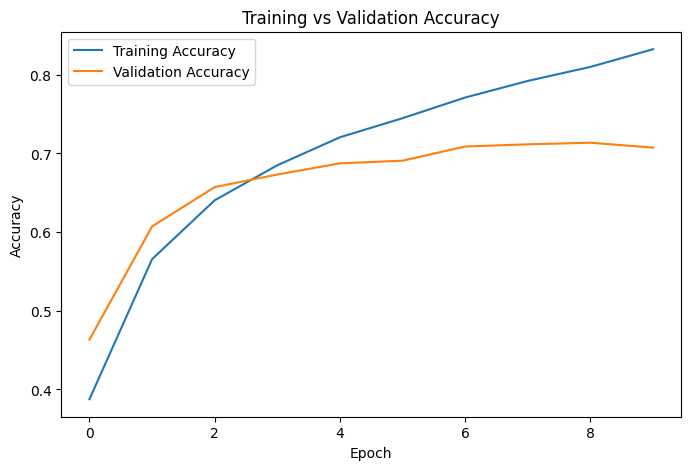

In [10]:
plt.figure(figsize=(8,5))

plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

In [11]:
# 11. TEST
model.eval()
correct = total = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = correct / total

print("Test Accuracy:", test_accuracy)


Test Accuracy: 0.7055


Saving ship.jfif to ship.jfif
Predicted class: ship
Logits: [ 1.3669422   0.03682546 -4.130806   -2.5838878  -4.8390455  -6.322331
 -4.758841   -5.9602523   4.505204   -0.2215535 ]


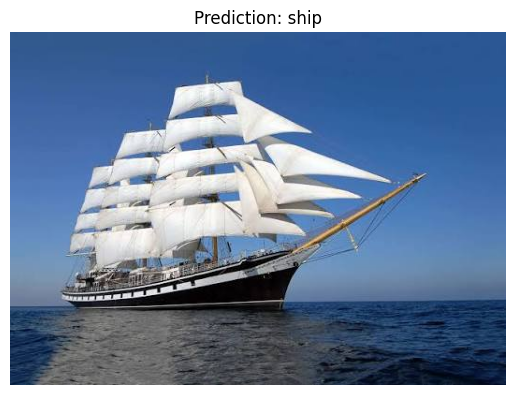

In [14]:
# 12. UPLOAD IMAGE
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# 13. READ AND RESIZE
img = Image.open(filename).convert("RGB")
img_resized = img.resize((32, 32))

# 14. CONVERT TO TENSOR
input_image = transforms.ToTensor()(img_resized)

# 15. ADD BATCH DIMENSION
input_image = input_image.unsqueeze(0)

# 16. PREDICTION
model.eval()

with torch.no_grad():
    logits = model(input_image)

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# 17. FIND PREDICTED CLASS
predicted_class = torch.argmax(logits[0]).item()

print("Predicted class:", class_names[predicted_class])
print("Logits:", logits[0].cpu().numpy())

# 18. DISPLAY IMAGE
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {class_names[predicted_class]}")
plt.show()